## 인텐시브 4기 머신러닝 대회 
- 데이터 house_prices.csv => 예측
- MSE 26 미만
- 행 삭제 금지
- 열 삭제는 2개까지만
- train / test 비율 기본값
- random_state = 0
- 배운 모형의 함수 활용
- 오름차순/내림차순 금지
- 대회신기록 9.8

In [1]:
import pandas as pd 
df = pd.read_csv('house_prices.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


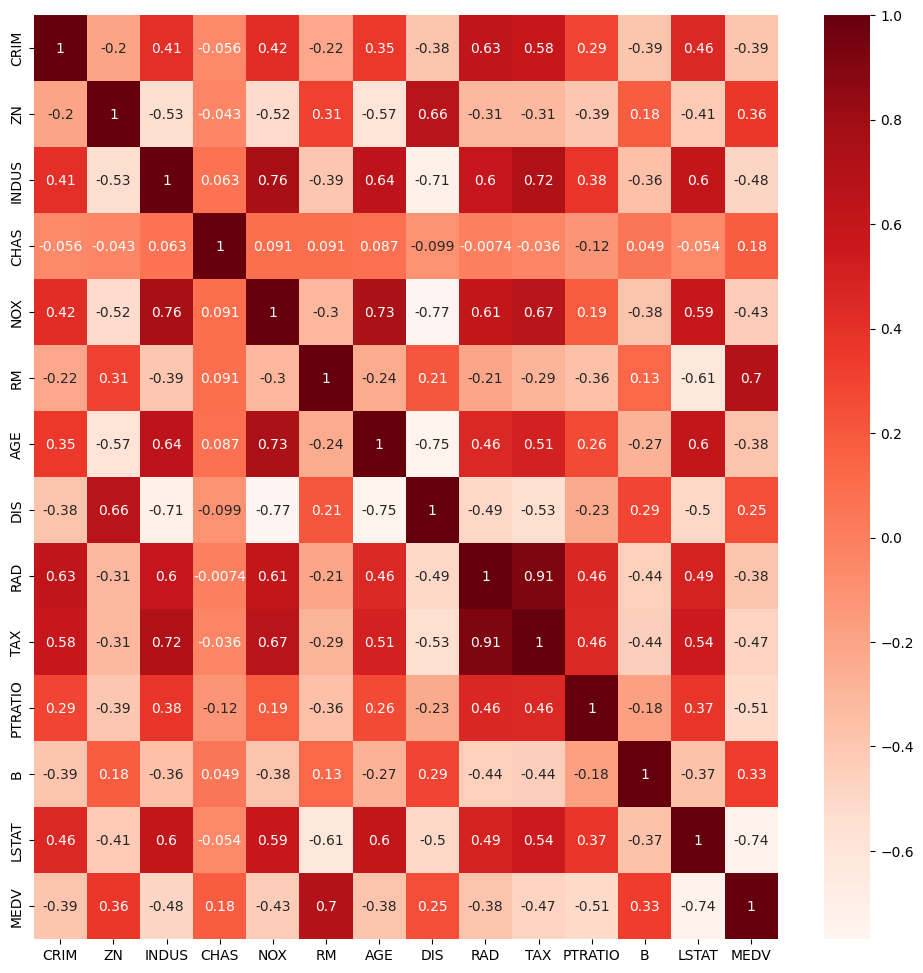

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True, cmap='Reds')  
pass   

#### 랜덤포레스트 

In [3]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [4]:
len(df.columns)

14

In [5]:
features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'] 

features = ['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']  # INDUS 삭제 


X = df[features]
y = df['MEDV']

In [6]:
# 트레이닝/테스트 데이터 분할
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0)

In [7]:
# 데이터 표준화
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [8]:
# 랜덤포레스트회귀 학습 
from sklearn.ensemble import RandomForestRegressor

clf_rf = RandomForestRegressor(max_depth=15, 
                               random_state=0, 
                               n_estimators=20, 
                               )
clf_rf.fit(X_tn_std, y_tn)

RandomForestRegressor(max_depth=15, n_estimators=20, random_state=0)

In [9]:
# 예측
rf_pred = clf_rf.predict(X_te_std)
# print(rf_pred)

In [10]:
# 모형평가 - MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_te, rf_pred)
print(mse)

13.509753921617987
